In [1]:
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
from gutBrainCode.gutBrainPipeline import loadGutBrainData,fitLeftGetThresh,pullAverages, pullTimes, getTrains, getTrainsTwoTypes, fusedLoocv, pullCells, pullCellMasks,makeBrainMap,shift,corr,pullCenters,pullLocs
from gutBrainCode.gutBrainPipeline import load,windowed_variance, meanAndSE

In [2]:
# Gathers the number of cores on cluster
nCPU = mp.cpu_count()

In [3]:
## Inputs and parameters
# Data and save paths
baseDir = '/nrs/ahrens/Weiyu_nrs/20220922_6mglucose_5mMglutamate_f18/exp0' # good


# Params
lsChannel = 2
uvChannel =10
galvoChannel = 22
thresh2 = 0.5
thresh = 3.8
gutPos = 2
ctrlPos = 1

# Regression params
lagOrder_gut = 50 # in frames
lagOrder_ctrl = 50 # in frames
lambdaRidge = 2
lambdaSmooth = 10
stdThresh = 2.5

In [4]:
# Gather meta, acquisition frequency
meta =np.load(baseDir+'/mika/parameters.pickle',allow_pickle=True)
acqFreq = 1/meta['f_volume']
resXY = meta['res_x']
resZ = meta['res_z']

In [5]:
# Load data, compute dff
dffTrace,ep,ephysFile, brainMap, VMask, V,W,X,Y,Z,nT,nCells,F = loadGutBrainData(baseDir)

/groups/ahrens/home/jamesb/gutBrainCode/gutBrainPipeline.py:108: RuntimeWarning: divide by zero encountered in divide
  dffTrace=(F[:,:]-base_f[:,:])/(base_f[:,:]-100) #100 is camera backgroud in spim2


In [6]:
# Find stack times, uv times, and uv locations
stackTimes, uvTimes,badStacks,galvo= pullTimes(ephysFile,2,uvChannel,galvoChannel,thresh)

In [7]:
# Construct time series
uvOnGut,uvOffGut, onTrain, offTrain,sp,visClosed, visISI,visGut,visISIGut,visISICtrl,visCtrl,visOpen=getTrains(ephysFile,ep,lsChannel,uvChannel,thresh,gutPos,ctrlPos,nT)


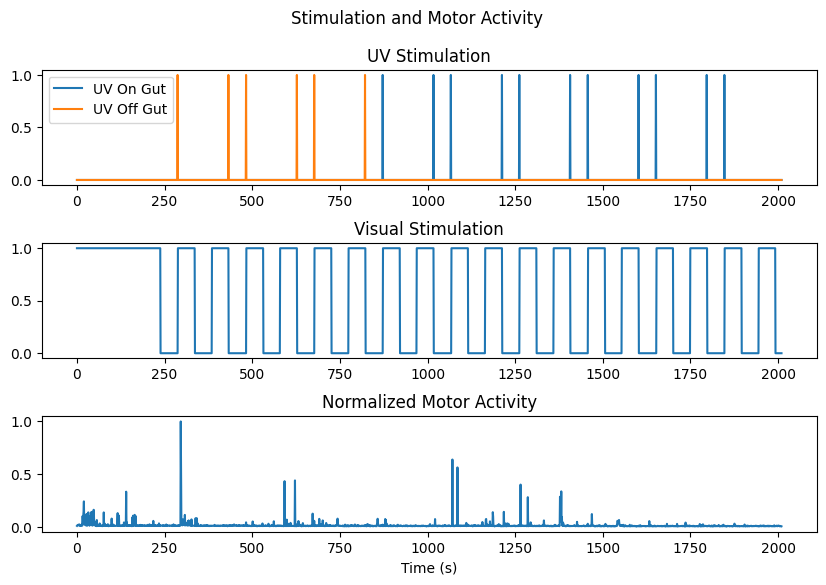

In [8]:
# Plot stimulation and motor activity traces
fig, axs = plt.subplots(3,figsize=(10,6))
plt.subplots_adjust(hspace=.5)
fig.suptitle('Stimulation and Motor Activity')
t= np.arange(0,len(onTrain))/acqFreq
axs[0].plot(t, onTrain,label = "UV On Gut")
axs[0].plot(t, offTrain,label = "UV Off Gut")
axs[0].legend()
axs[0].set_title("UV Stimulation")
axs[1].plot(t,visOpen)
axs[1].set_title("Visual Stimulation")
axs[2].plot(t,sp/np.max(sp))
axs[2].set_title("Normalized Motor Activity")
axs[2].set_xlabel("Time (s)")
plt.show()

In [9]:
## Run parts model
regMat = np.vstack((onTrain,offTrain+onTrain)) # Regressors for full model
typeVec = [lagOrder_gut,lagOrder_ctrl] # Lag orders for full model
regMat2 = onTrain+offTrain # Regressor for part model
typeVec2=[lagOrder_ctrl] # lag order for part model
## Run regression
mod= fusedLoocv(50,lambdaRidge,lambdaSmooth)
mod.runBothModels(dffTrace,regMat,typeVec,regMat2,typeVec2,uvOnGut)

Running trial 1 of 12


/groups/ahrens/home/jamesb/gutBrainCode/gutBrainPipeline.py:542: RuntimeWarning: invalid value encountered in divide
  c = num/den


Running trial 2 of 12
Running trial 3 of 12
Running trial 4 of 12
Running trial 5 of 12
Running trial 6 of 12
Running trial 7 of 12
Running trial 8 of 12
Running trial 9 of 12
Running trial 10 of 12
Running trial 11 of 12


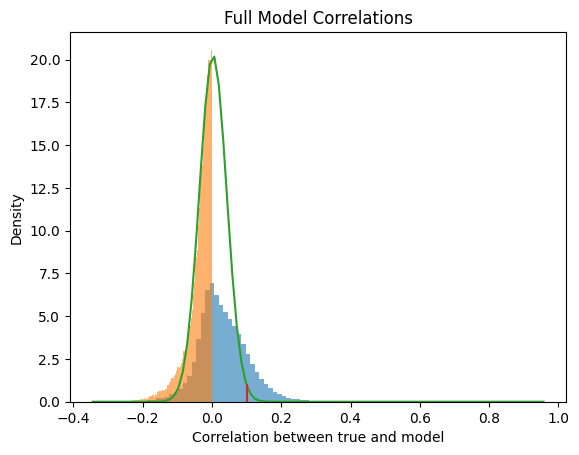

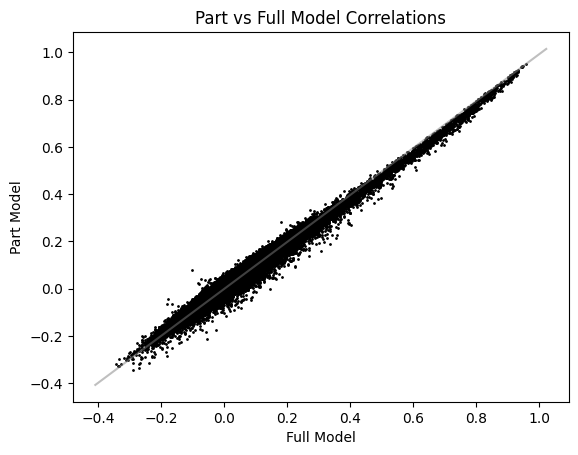

In [10]:
# Find threshold for signifanct correlations
thresh = fitLeftGetThresh(np.mean(mod.corr,axis=0),stdThresh)
plt.title("Full Model Correlations")
plt.ylabel("Density")
plt.xlabel("Correlation between true and model")
plt.show()

#fig,ax = plt.figure()
plt.scatter(np.mean(mod.corr,axis=0),np.mean(mod.corr2,axis=0),c='k',s=1)
plt.xlabel("Full Model")
plt.ylabel("Part Model")
xmin, xmax, ymin, ymax= plt.axis()
plt.plot([xmin,xmax],[ymin,ymax],alpha =.5,c='.5')
plt.title("Part vs Full Model Correlations")
plt.show()


In [11]:
### Pull gut-related cells
firstPass,secondPass,thirdPass,secondPassP,thirdPassP = pullCells(mod,thresh[0],.1,0,50,uvOnGut,uvOffGut[:-1]) # alpha value for comparison control and gut
gutCells = thirdPass
gutDFF = dffTrace[gutCells,:]
print(str(len(gutCells)) + " selected from " + str(len(dffTrace)) + " cells.")

2746 selected from 195852 cells.


In [12]:
## Pull average responses of selected cells
gutResps, gutMeans,gutSEs = meanAndSE(gutDFF,uvOnGut,10,50)
ctrlResps, ctrlMeans,ctrlSEs = meanAndSE(gutDFF,uvOffGut,10,50)

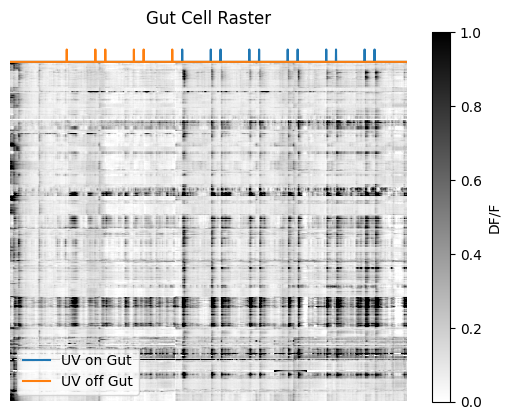

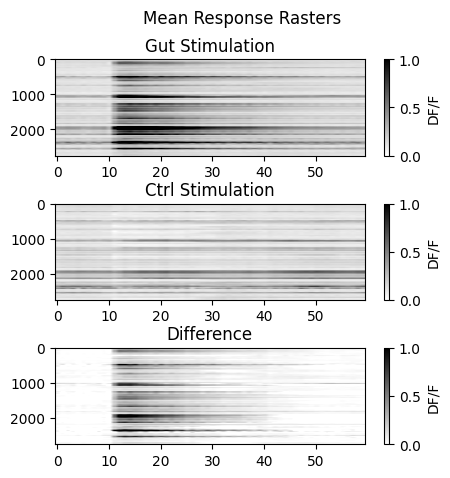

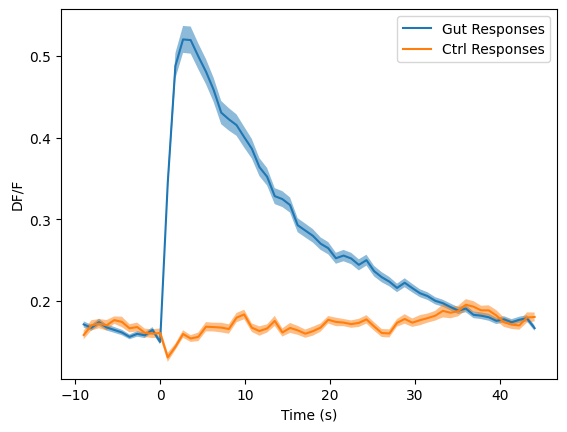

In [13]:
plt.imshow(gutDFF,vmin = 0,vmax = 1,aspect = 'auto',cmap = 'gray_r')
plt.axis('off')
plt.plot(onTrain*-100,label = "UV on Gut")
plt.plot(offTrain*-100,label = "UV off Gut")
plt.legend()
plt.title("Gut Cell Raster")
plt.colorbar(label = "DF/F")
plt.xlabel("Time (s)")
plt.ylabel("Gut-responsive Cells")
plt.show()


fig,axs = plt.subplots(3,figsize = (5,5))
fig.suptitle('Mean Response Rasters')
plt.subplots_adjust(hspace=.5)
im = axs[0].imshow(gutMeans,aspect = 'auto',vmin = 0, vmax= 1,cmap = 'gray_r')
axs[1].imshow(ctrlMeans,aspect = 'auto',vmin = 0, vmax= 1,cmap = 'gray_r')
axs[2].imshow(gutMeans-ctrlMeans,aspect = 'auto',vmin = 0, vmax= 1,cmap = 'gray_r') 
fig.colorbar(im,ax=axs[0],label = "DF/F")
fig.colorbar(im,ax=axs[1],label = "DF/F")
fig.colorbar(im,ax=axs[2],label = "DF/F")
axs[0].set_title('Gut Stimulation')
axs[1].set_title("Ctrl Stimulation")
axs[2].set_title("Difference")
plt.show()

grandMean = np.mean(gutMeans,axis=0)
grandSE = np.std(gutMeans,axis=0)/np.sqrt(len(gutMeans))
grandMeanCtrl = np.mean(ctrlMeans,axis=0)
grandSECtrl = np.std(ctrlMeans,axis=0)/np.sqrt(len(ctrlMeans))
xxResp = np.arange(-10,50) /acqFreq
plt.plot(xxResp,grandMean,label = "Gut Responses")
plt.fill_between(xxResp, grandMean-grandSE, grandMean+grandSE,alpha = .5)
plt.plot(xxResp,grandMeanCtrl,label = "Ctrl Responses")
plt.fill_between(xxResp, grandMeanCtrl-grandSECtrl, grandMeanCtrl+grandSECtrl,alpha = .5)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("DF/F")
plt.show()

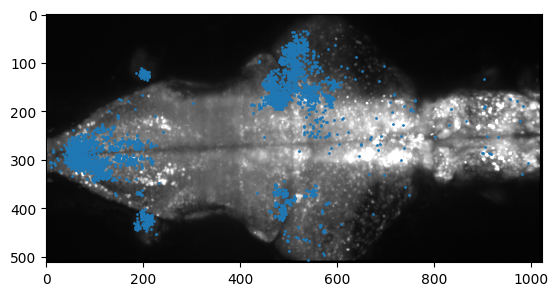

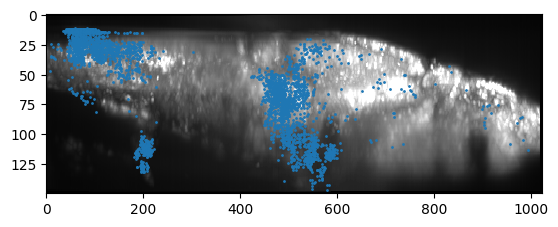

In [14]:
# Map selected cells
centers = pullCenters(X[gutCells],Y[gutCells],Z[gutCells])
plt.imshow(brainMap[:,:,:-1].max(axis=2).T, vmin=100,vmax=np.percentile(brainMap[:].squeeze(), 99.98),cmap='gray',aspect = 1)
plt.scatter(centers[:,0],centers[:,1],s=1)
plt.show()
plt.imshow(np.flip(brainMap[:,:,:-1].max(axis=1).T,axis=0), cmap='gray',vmin =100, vmax=np.percentile(brainMap[:].squeeze(), 99.98),interpolation='nearest',aspect= resZ/(resXY*2))
plt.scatter(centers[:,0],brainMap.shape[2]-centers[:,2],s=1)
plt.show()

/groups/ahrens/home/jamesb/micromamba/envs/jupyterEnv/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


2520


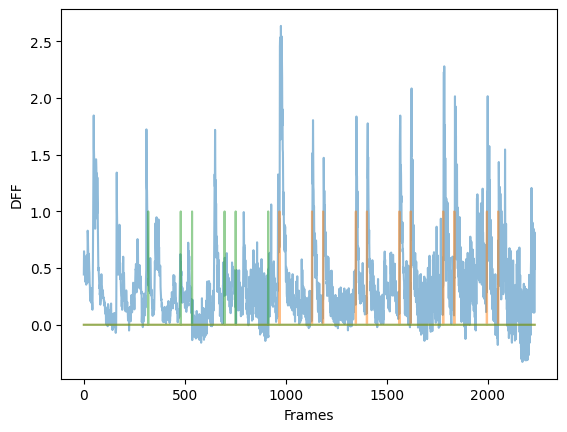

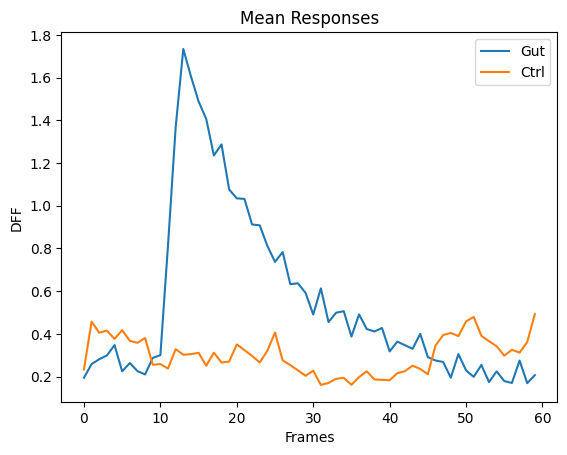

2326


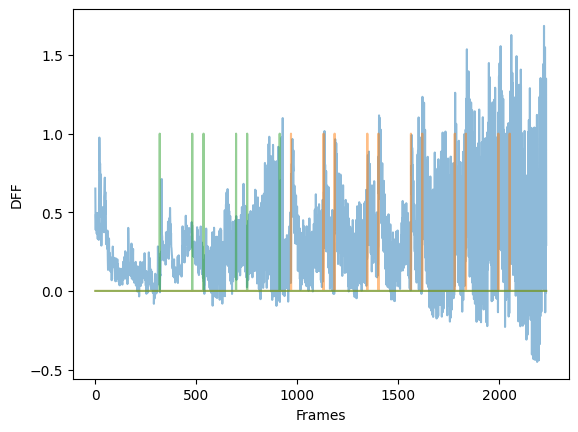

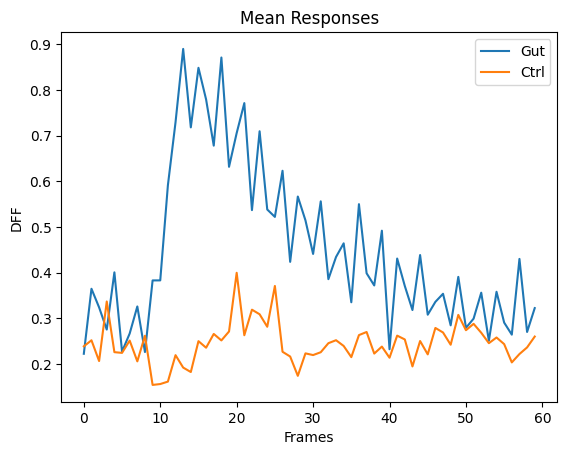

1386


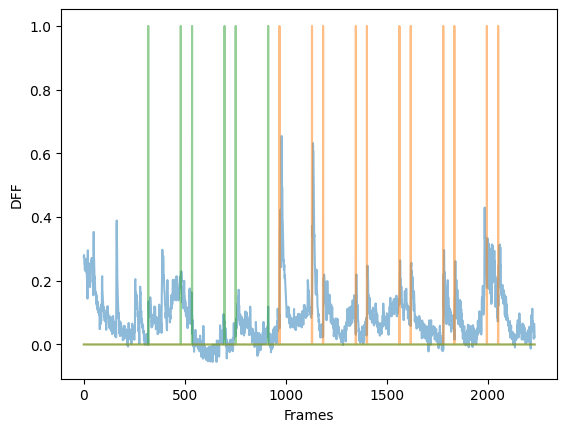

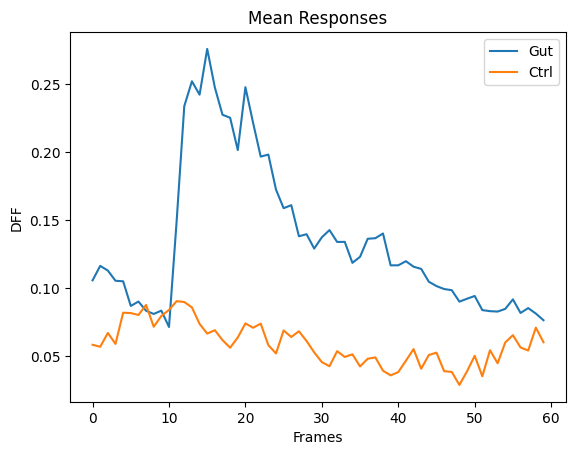

1864


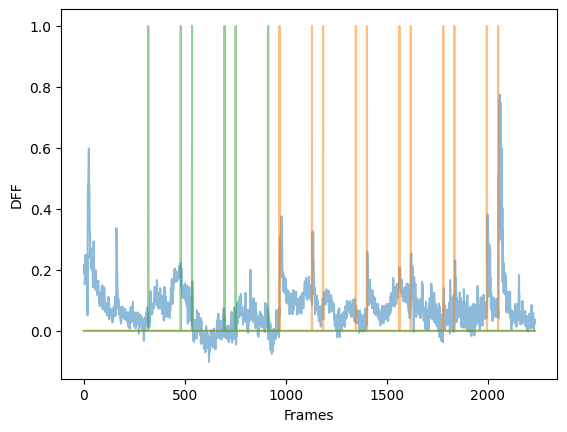

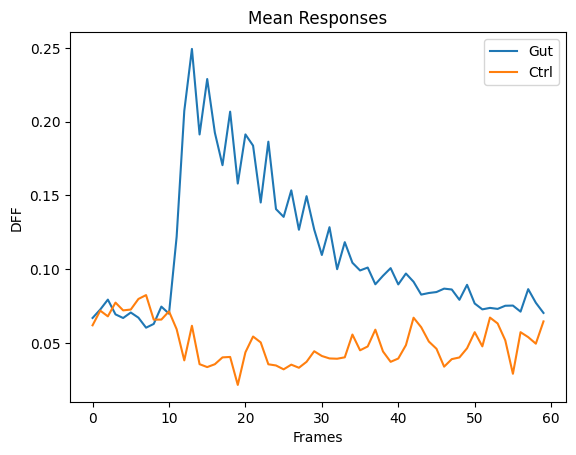

830


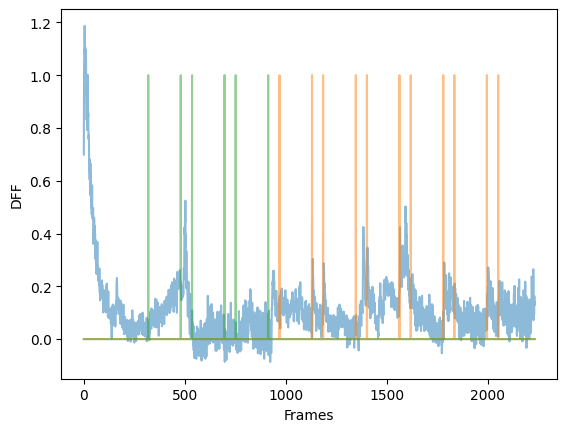

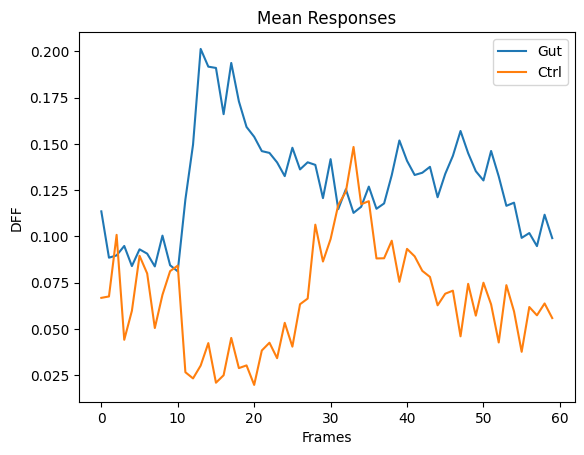

In [15]:
# Plot a subset of data for validation
randSelection = np.random.choice(np.arange(len(gutCells)),size = 5)
aveGutResponse, seGutResponse,aveCtrlResponse,seCtrlResponse = pullAverages(dffTrace,uvOnGut,uvOffGut,10,35)
for i in randSelection:
    print(i)
    plt.plot(gutDFF[i,:],alpha = .5)
    plt.plot(onTrain,alpha=.5)
    plt.plot(offTrain,alpha = .5)
    plt.xlabel("Frames")
    plt.ylabel("DFF")
    plt.show()
    plt.plot(gutMeans[i,:],label = "Gut")
    plt.plot(ctrlMeans[i,:],label = "Ctrl")
    plt.xlabel("Frames")
    plt.ylabel("DFF")
    plt.title("Mean Responses")
    plt.legend()
    plt.show()